# Conditional GAN Training: Stabilization and Tuning

## Motivation

### Recap of Baseline

We implemented a conditional GAN (cGAN) for Fashion-MNIST generation. The baseline architecture followed the standard cGAN approach:
- **Generator:** Takes random noise (100-dim) and class labels, produces 28×28 grayscale images
- **Discriminator:** Takes images and class labels, outputs real/fake logits
- **Training:** Standard GAN training with Binary Cross-Entropy loss

### Problem Identification

After training the baseline model for 50 epochs, we observed several issues:

| Observation | Implication |
|------------|-------------|
| Discriminator loss consistently decreases (0.55 → 0.2) | Discriminator becomes too strong |
| Generator loss increases in later epochs (1.5 → 3.0) | Vanishing gradients for generator |
| High volatility in G_loss (jumps from 0.9 to 3.0) | Unstable training dynamics |
| Late-stage discriminator dominance | Risk of mode collapse |

**Key Challenge:** The discriminator learns too quickly and dominates the game, leaving the generator with weak gradients. This is a classic problem in GAN training.

### Objectives

1. **Stabilize GAN training dynamics** - Reduce loss volatility and prevent discriminator dominance
2. **Improve generation quality** - Produce sharper, more diverse images
3. **Document best practices** for conditional GAN training on Fashion-MNIST

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import pandas as pd
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Hyperparameters (baseline)
batch_size = 128
z_dim = 100
num_classes = 10
img_size = 28
channels = 1
lr = 0.0002
betas = (0.5, 0.999)
num_epochs = 50

Using device: cuda


## Baseline Reproduction

Before experimenting with new techniques, we'll reproduce our baseline model to establish a reference point for comparison.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Load training dataset
train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", 
    train=True, 
    download=True, 
    transform=transform
)

# Create data loader
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

# Class names for reference
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Dataset size: {len(train_dataset)} images")
print(f"Number of batches per epoch: {len(train_loader)}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.58MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.8MB/s]

Dataset size: 60000 images
Number of batches per epoch: 468


In [3]:
class Generator(nn.Module):
    """Conditional Generator for Fashion-MNIST (Baseline)"""
    def __init__(self, z_dim=100, num_classes=10, img_size=28, channels=1):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, z_dim)
        self.init_size = img_size // 4  # 7 for 28x28 images
        
        self.l1 = nn.Sequential(
            nn.Linear(z_dim * 2, 128 * self.init_size ** 2),
            nn.BatchNorm1d(128 * self.init_size ** 2),
            nn.ReLU(inplace=True),
        )
        
        self.conv_blocks = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, channels, 4, stride=2, padding=1),
            nn.Tanh(),
        )
    
    def forward(self, z, labels):
        label_emb = self.label_emb(labels)
        gen_input = torch.cat((z, label_emb), dim=1)
        out = self.l1(gen_input)
        out = out.view(out.size(0), 128, self.init_size, self.init_size)
        return self.conv_blocks(out)


class Discriminator(nn.Module):
    """Conditional Discriminator for Fashion-MNIST (Baseline)"""
    def __init__(self, img_size=28, channels=1, num_classes=10):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, 1)
        self.img_size = img_size
        
        self.model = nn.Sequential(
            nn.Conv2d(channels + 1, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(128 * (img_size // 4) * (img_size // 4), 1),
        )
    
    def forward(self, img, labels):
        label_input = self.label_emb(labels).view(-1, 1, 1, 1)
        label_input = label_input.expand(-1, 1, self.img_size, self.img_size)
        x = torch.cat((img, label_input), dim=1)
        return self.model(x)

### Baseline Training Function

We'll create a flexible training function that can incorporate our stabilization techniques.

In [4]:
class GANTrainer:    
    def __init__(self, G, D, train_loader, device):
        self.G = G
        self.D = D
        self.train_loader = train_loader
        self.device = device
        self.fixed_z = torch.randn(num_classes, z_dim, device=device)  # For consistent visualization
        self.fixed_labels = torch.arange(num_classes, device=device)
        
        # Metrics storage
        self.history = {
            'G_loss': [],
            'D_loss': [],
            'epoch': []
        }
    
    def train_epoch(self, optimizer_G, optimizer_D, criterion, epoch, techniques={}):
        """
        Train for one epoch with optional techniques
        
        Args:
            techniques: dict with keys like 'label_smoothing', 'gradient_penalty', etc.
        """
        self.G.train()
        self.D.train()
        
        epoch_g_loss = 0
        epoch_d_loss = 0
        
        pbar = tqdm(self.train_loader, desc=f"Epoch {epoch}")
        
        for i, (real_imgs, labels) in enumerate(pbar):
            real_imgs = real_imgs.to(self.device)
            labels = labels.to(self.device)
            current_batch_size = real_imgs.size(0)
            
            # train Discriminator
            optimizer_D.zero_grad()
            
            # Real images loss
            real_validity = self.D(real_imgs, labels)
            
            # Apply label smoothing if specified
            if techniques.get('label_smoothing', False):
                real_target = torch.ones(current_batch_size, 1, device=self.device) * 0.9
                fake_target = torch.zeros(current_batch_size, 1, device=self.device) + 0.1
            else:
                real_target = torch.ones(current_batch_size, 1, device=self.device)
                fake_target = torch.zeros(current_batch_size, 1, device=self.device)
            
            real_loss = criterion(real_validity, real_target)
            
            # Fake images loss
            z = torch.randn(current_batch_size, z_dim, device=self.device)
            fake_imgs = self.G(z, labels)
            fake_validity = self.D(fake_imgs.detach(), labels)
            fake_loss = criterion(fake_validity, fake_target)
            
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()
            
            # train Generator
            optimizer_G.zero_grad()
            
            z = torch.randn(current_batch_size, z_dim, device=self.device)
            fake_imgs = self.G(z, labels)
            fake_validity = self.D(fake_imgs, labels)
            
            g_loss = criterion(fake_validity, torch.ones(current_batch_size, 1, device=self.device))
            g_loss.backward()
            optimizer_G.step()
            
            # Update metrics
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
            
            # Update progress bar
            pbar.set_postfix({
                "D_loss": f"{d_loss.item():.4f}",
                "G_loss": f"{g_loss.item():.4f}"
            })
        
        # Average losses
        avg_g_loss = epoch_g_loss / len(self.train_loader)
        avg_d_loss = epoch_d_loss / len(self.train_loader)
        
        return avg_g_loss, avg_d_loss
    
    def train(self, num_epochs, optimizer_G, optimizer_D, criterion, techniques={}, save_interval=5):        
        for epoch in range(1, num_epochs + 1):
            g_loss, d_loss = self.train_epoch(
                optimizer_G, optimizer_D, criterion, epoch, techniques
            )
            
            self.history['G_loss'].append(g_loss)
            self.history['D_loss'].append(d_loss)
            self.history['epoch'].append(epoch)
            
            if epoch % save_interval == 0 or epoch == 1:
                self.visualize(epoch)
                # self.plot_losses()
        
        return self.history
    
    def visualize(self, epoch):
        self.G.eval()
        with torch.no_grad():
            fake_imgs = self.G(self.fixed_z, self.fixed_labels)
            fake_imgs = fake_imgs * 0.5 + 0.5  # Denormalize
            
            grid = make_grid(fake_imgs, nrow=5, normalize=False)
            plt.figure(figsize=(12, 4))
            plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
            plt.title(f"Epoch {epoch} — One sample per class")
            plt.axis("off")
            plt.show()
        self.G.train()
    
    def plot_losses(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.history['epoch'], self.history['G_loss'], label='Generator Loss', alpha=0.7)
        plt.plot(self.history['epoch'], self.history['D_loss'], label='Discriminator Loss', alpha=0.7)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Losses')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

Epoch 1: 100%|██████████| 468/468 [00:09<00:00, 46.86it/s, D_loss=0.4838, G_loss=1.0647]


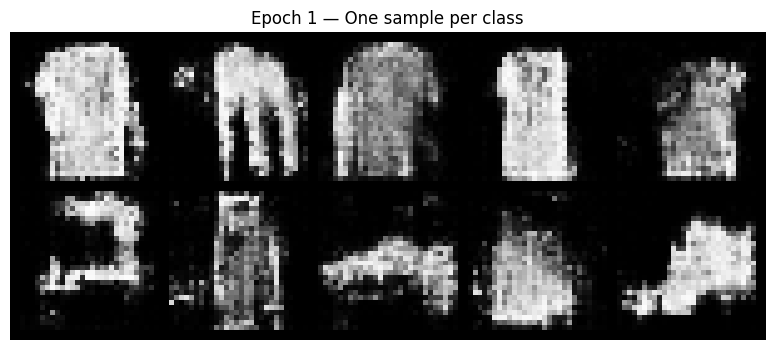

Epoch 10: 100%|██████████| 468/468 [00:08<00:00, 54.77it/s, D_loss=0.4288, G_loss=1.7661]


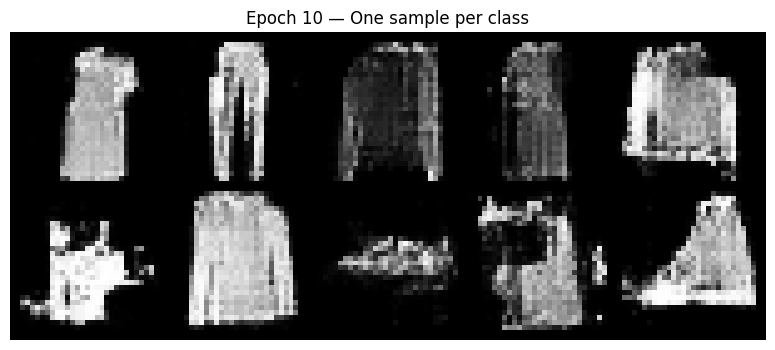

Epoch 20: 100%|██████████| 468/468 [00:08<00:00, 52.78it/s, D_loss=0.3138, G_loss=1.5394]


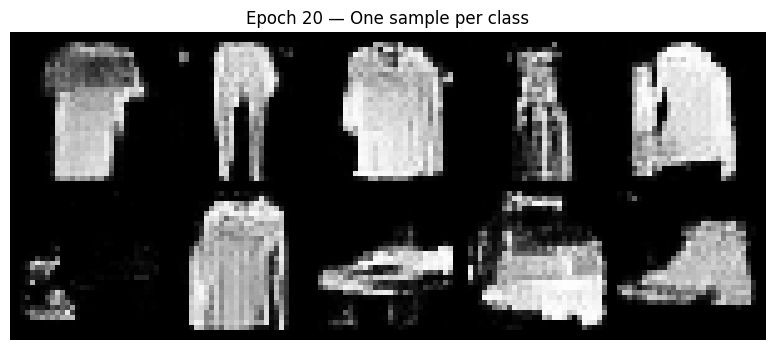

Epoch 30: 100%|██████████| 468/468 [00:08<00:00, 52.88it/s, D_loss=0.2662, G_loss=2.1807]


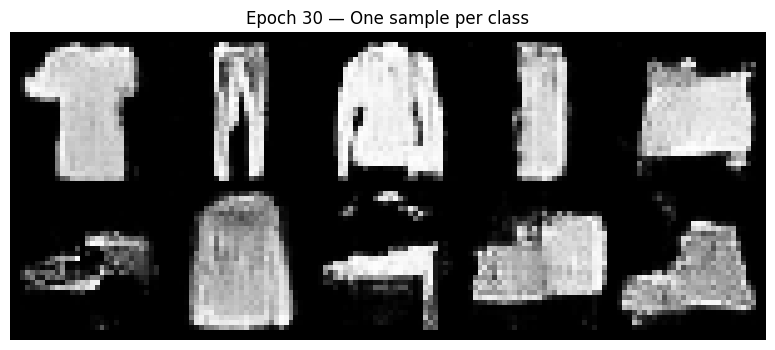

Epoch 40: 100%|██████████| 468/468 [00:08<00:00, 53.80it/s, D_loss=0.2438, G_loss=3.2651]


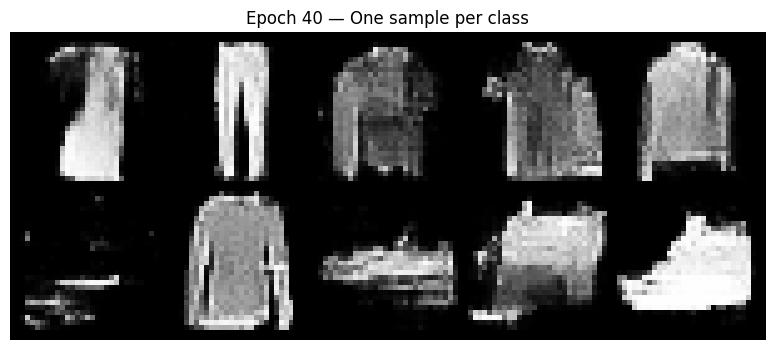

Epoch 50: 100%|██████████| 468/468 [00:08<00:00, 53.84it/s, D_loss=0.1265, G_loss=3.3532]


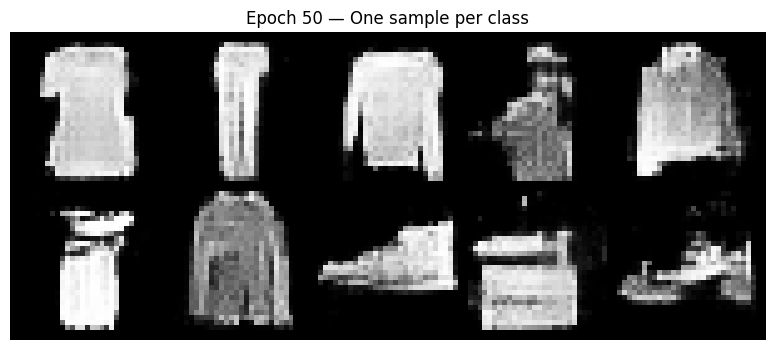


Baseline training completed!


In [5]:
G_baseline = Generator(z_dim, num_classes, img_size, channels).to(device)
D_baseline = Discriminator(img_size, channels, num_classes).to(device)

optimizer_G = optim.Adam(G_baseline.parameters(), lr=lr, betas=betas)
optimizer_D = optim.Adam(D_baseline.parameters(), lr=lr, betas=betas)

criterion = nn.BCEWithLogitsLoss()

trainer_baseline = GANTrainer(G_baseline, D_baseline, train_loader, device)

baseline_history = trainer_baseline.train(
    num_epochs=num_epochs,
    optimizer_G=optimizer_G,
    optimizer_D=optimizer_D,
    criterion=criterion,
    techniques={},  # No techniques for baseline
    save_interval=10
)

print("\nBaseline training completed!")

## Key Findings from Baseline Analysis

| Issue | Evidence | Impact |
|-------|----------|--------|
| **Discriminator dominance** | D loss decreases steadily to ~0.2 | Generator gradients vanish |
| **Generator instability** | High G loss volatility | Inconsistent generation quality |
| **Increasing G loss** | G loss grows from 1.5 → 3.0 | Generator isn't improving |
| **Poor balance** | G/D ratio > 5 in late epochs | Unhealthy competition |

## Stabilization Techniques

Now we'll systematically apply and evaluate various techniques to address the identified issues. Each technique will be explained theoretically, then implemented and tested.

### Label Smoothing

**Theory:** 
Standard GAN training uses hard labels (1 for real, 0 for fake). This can make the discriminator too confident, leading to vanishing gradients. Label smoothing replaces hard targets with soft values (e.g., 0.9 for real, 0.1 for fake).

Epoch 1: 100%|██████████| 468/468 [00:08<00:00, 56.19it/s, D_loss=0.5098, G_loss=1.4546]


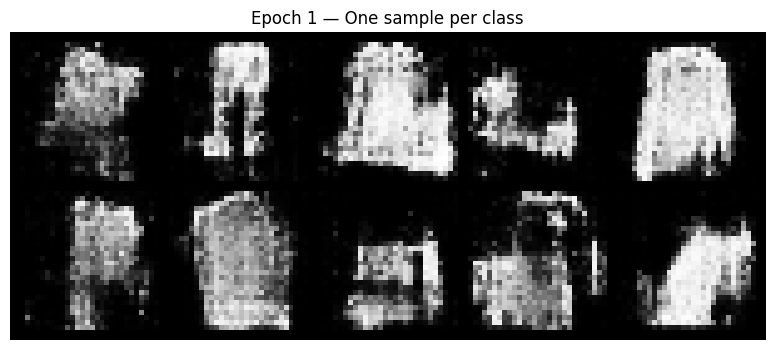

Epoch 10: 100%|██████████| 468/468 [00:08<00:00, 54.87it/s, D_loss=0.5354, G_loss=1.1824]


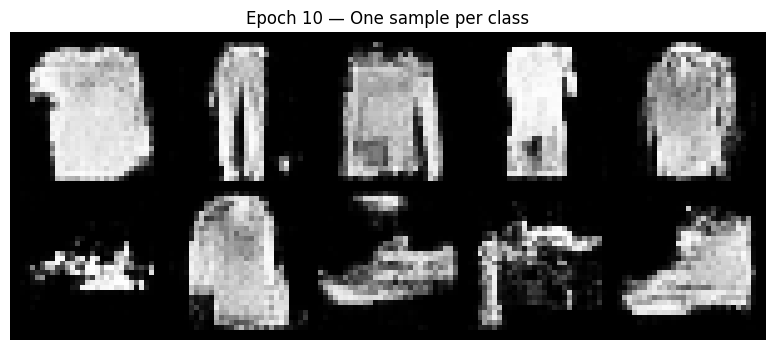

Epoch 20: 100%|██████████| 468/468 [00:08<00:00, 53.02it/s, D_loss=0.5015, G_loss=1.2968]


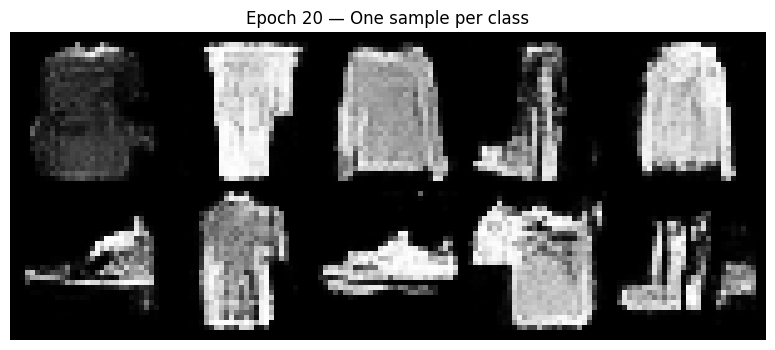

Epoch 30: 100%|██████████| 468/468 [00:08<00:00, 53.72it/s, D_loss=0.4996, G_loss=1.4957]


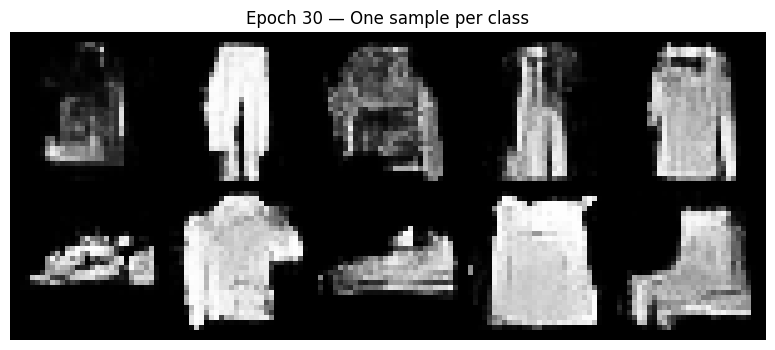

Epoch 40: 100%|██████████| 468/468 [00:08<00:00, 54.37it/s, D_loss=0.4617, G_loss=1.6600]


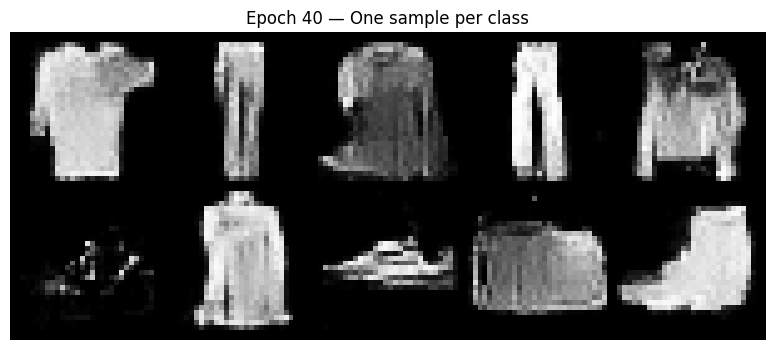

Epoch 50: 100%|██████████| 468/468 [00:08<00:00, 53.68it/s, D_loss=0.4721, G_loss=1.8572]


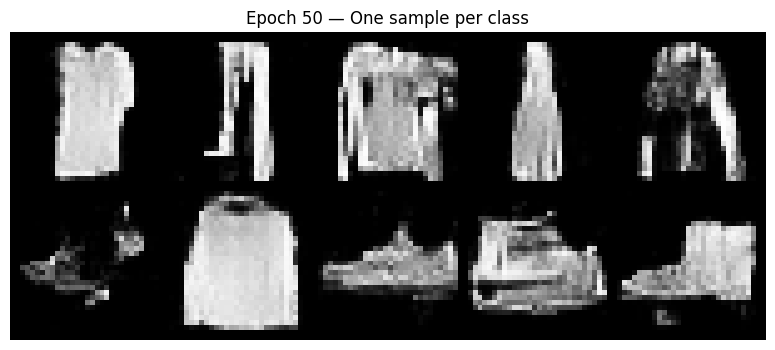


Label Smoothing experiment completed!


In [6]:
# fresh start for fair comparison
G_ls = Generator(z_dim, num_classes, img_size, channels).to(device)
D_ls = Discriminator(img_size, channels, num_classes).to(device)

optimizer_G_ls = optim.Adam(G_ls.parameters(), lr=lr, betas=betas)
optimizer_D_ls = optim.Adam(D_ls.parameters(), lr=lr, betas=betas)

trainer_ls = GANTrainer(G_ls, D_ls, train_loader, device)

techniques_ls = {
    'label_smoothing': True
}

history_ls = trainer_ls.train(
    num_epochs=num_epochs,
    optimizer_G=optimizer_G_ls,
    optimizer_D=optimizer_D_ls,
    criterion=criterion,
    techniques=techniques_ls,
    save_interval=10
)

print("\nLabel Smoothing experiment completed!")

#### Label Smoothing Results Analysis

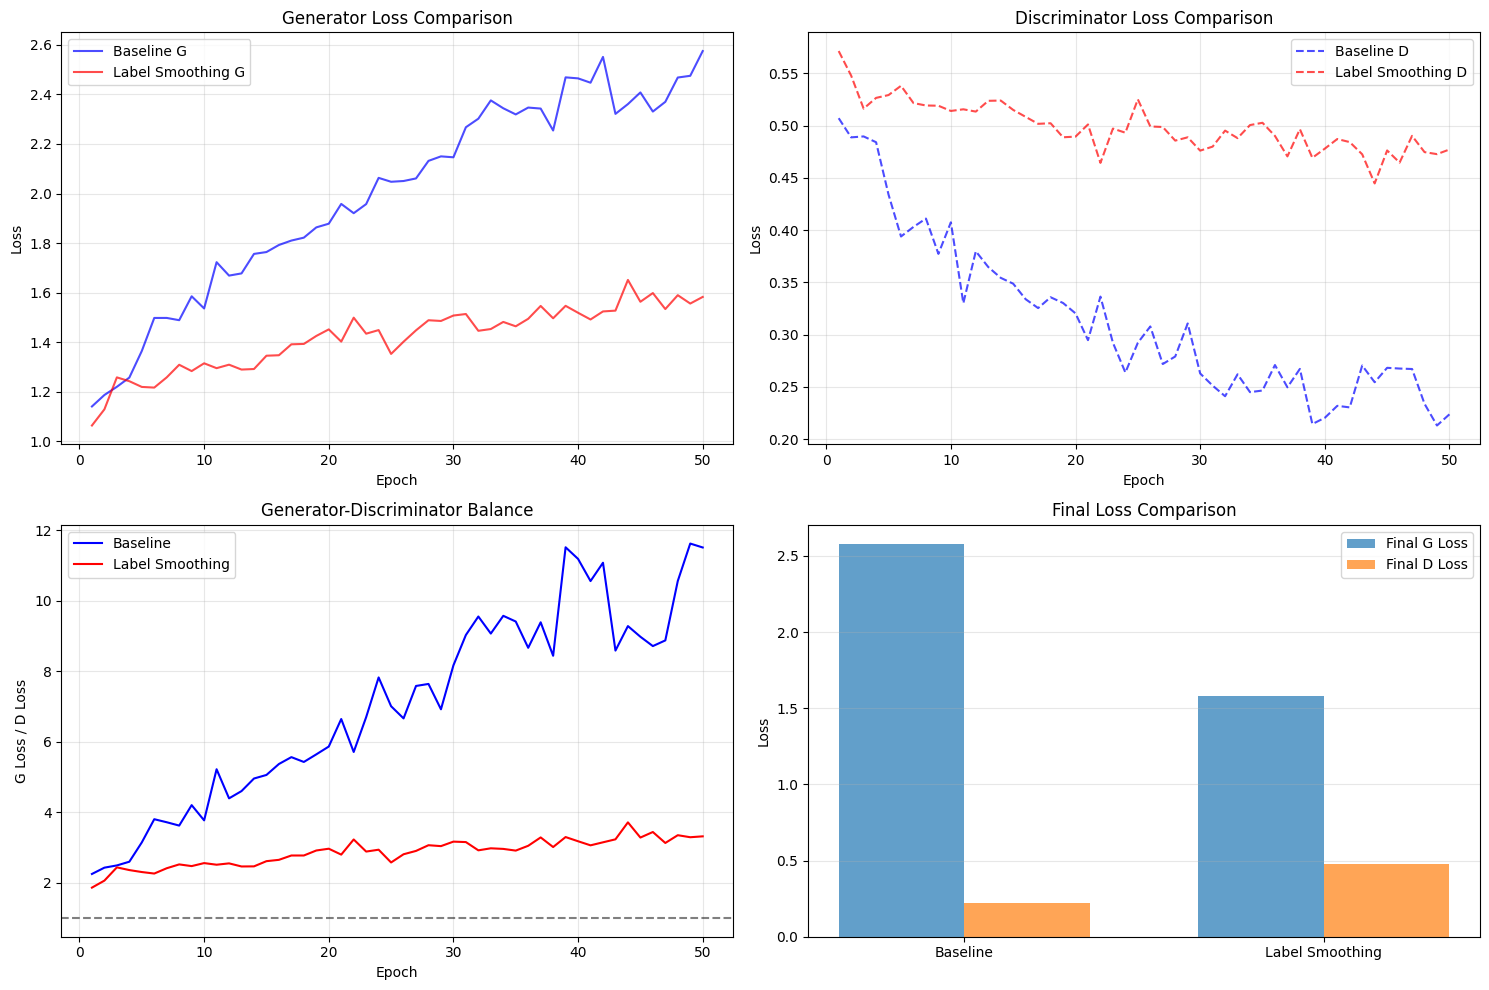

In [7]:
def compare_experiments(histories, labels):    
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: G Loss comparison
    ax = axes[0, 0]
    for i, (name, history) in enumerate(histories.items()):
        ax.plot(history['epoch'], history['G_loss'], 
                label=f"{name} G", color=colors[i], linestyle='-', alpha=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Generator Loss Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: D Loss comparison
    ax = axes[0, 1]
    for i, (name, history) in enumerate(histories.items()):
        ax.plot(history['epoch'], history['D_loss'], 
                label=f"{name} D", color=colors[i], linestyle='--', alpha=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Discriminator Loss Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: G/D Ratio comparison
    ax = axes[1, 0]
    for i, (name, history) in enumerate(histories.items()):
        ratio = np.array(history['G_loss']) / (np.array(history['D_loss']) + 1e-8)
        ax.plot(history['epoch'], ratio, label=name, color=colors[i])
    ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('G Loss / D Loss')
    ax.set_title('Generator-Discriminator Balance')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Final loss comparison (bar chart)
    ax = axes[1, 1]
    x_pos = np.arange(len(histories))
    width = 0.35
    
    g_final = [history['G_loss'][-1] for history in histories.values()]
    d_final = [history['D_loss'][-1] for history in histories.values()]
    
    ax.bar(x_pos - width/2, g_final, width, label='Final G Loss', alpha=0.7)
    ax.bar(x_pos + width/2, d_final, width, label='Final D Loss', alpha=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(histories.keys())
    ax.set_ylabel('Loss')
    ax.set_title('Final Loss Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

histories = {
    'Baseline': baseline_history,
    'Label Smoothing': history_ls
}

compare_experiments(histories, ['Baseline', 'Label Smoothing'])

#### Label Smoothing: Visual Results

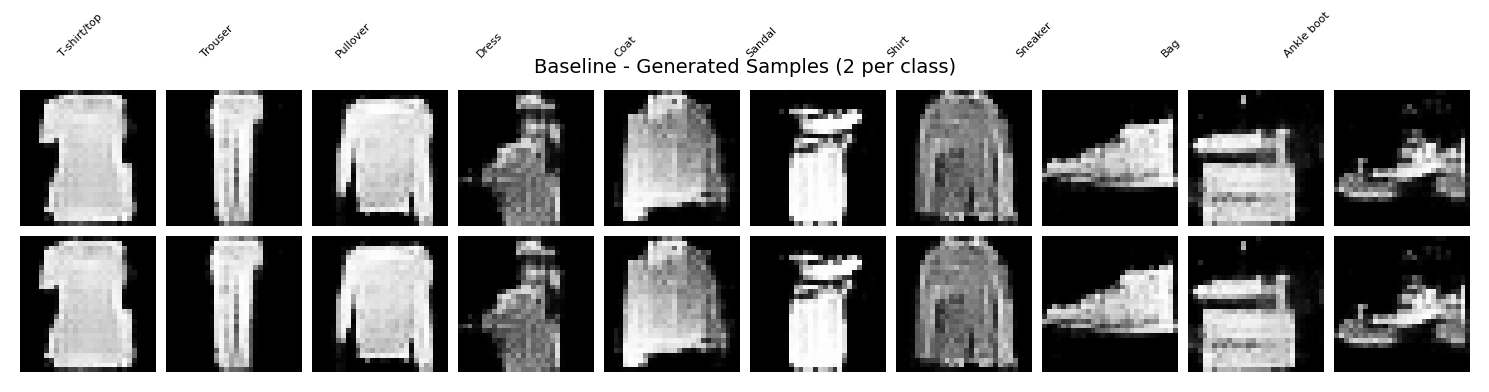

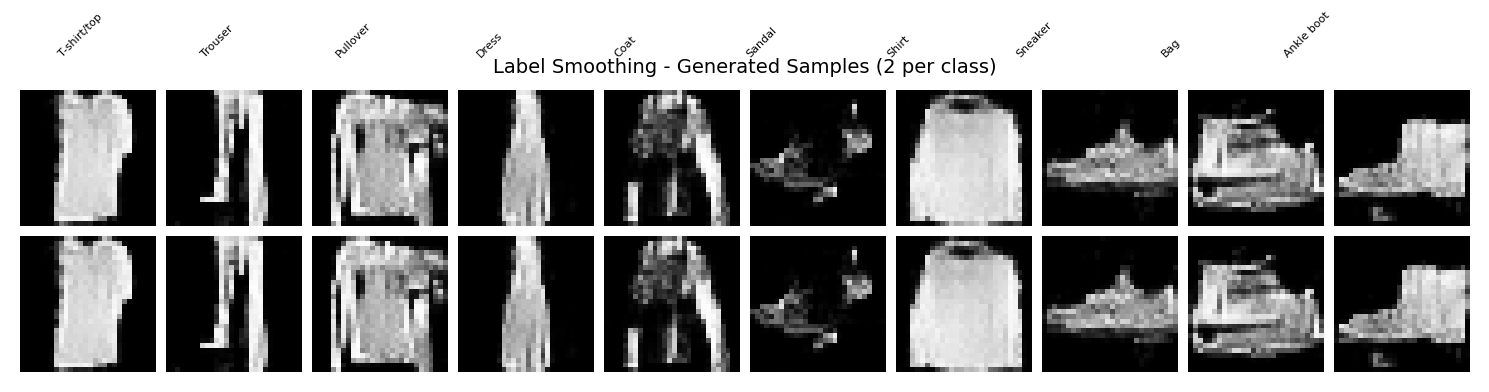

In [8]:
def display_experiment_samples(trainer, experiment_name):
    """Display generated samples from an experiment"""
    
    trainer.G.eval()
    with torch.no_grad():
        # Generate samples for all classes
        z = torch.randn(num_classes * 2, z_dim, device=device)
        labels = torch.tensor(list(range(num_classes)) * 2, device=device)
        
        samples = trainer.G(z, labels)
        samples = samples * 0.5 + 0.5
        
        grid = make_grid(samples, nrow=num_classes, normalize=False, pad_value=1)
        
        plt.figure(figsize=(15, 4))
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.title(f"{experiment_name} - Generated Samples (2 per class)", fontsize=14)
        plt.axis('off')
        
        # Add class labels
        for i, name in enumerate(class_names):
            plt.text(i * 28 + 14, -5, name, ha='center', va='bottom', fontsize=8, rotation=45)
        
        plt.tight_layout()
        plt.show()
    trainer.G.train()

display_experiment_samples(trainer_baseline, "Baseline")
display_experiment_samples(trainer_ls, "Label Smoothing")

### Learning Rate Tuning

**Theory:**
The balance between generator and discriminator learning rates is crucial. In many successful GAN implementations, the discriminator learns faster than the generator. We'll experiment with different learning rate ratios:

- **Option A:** Lower D learning rate (slows down discriminator)
- **Option B:** Higher G learning rate (helps generator catch up)
- **Option C:** Learning rate scheduling (decay over time)

**Hypothesis:** A smaller learning rate for the discriminator (or larger for generator) might prevent it from dominating too quickly.

Testing configuration: Slow D (G: 0.0002, D: 0.0001)


Epoch 1: 100%|██████████| 468/468 [00:08<00:00, 52.92it/s, D_loss=0.6152, G_loss=0.8591]


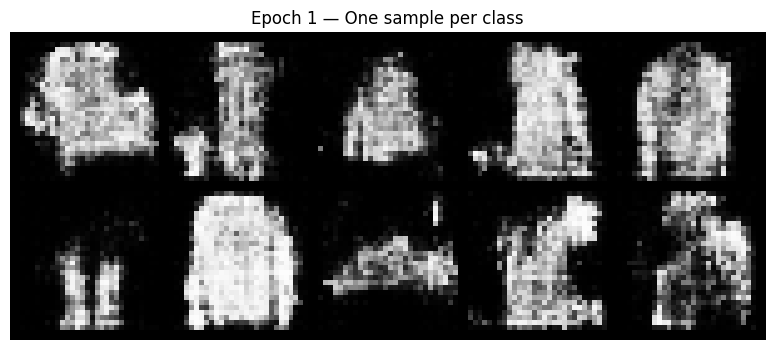

Epoch 10: 100%|██████████| 468/468 [00:08<00:00, 54.49it/s, D_loss=0.6422, G_loss=0.8510]


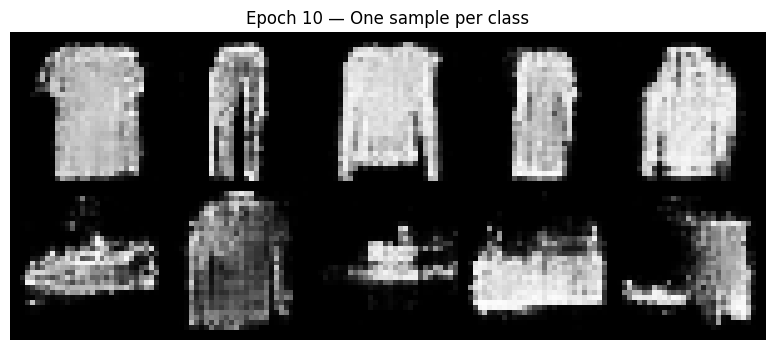

Epoch 20: 100%|██████████| 468/468 [00:08<00:00, 54.42it/s, D_loss=0.6405, G_loss=0.8805]


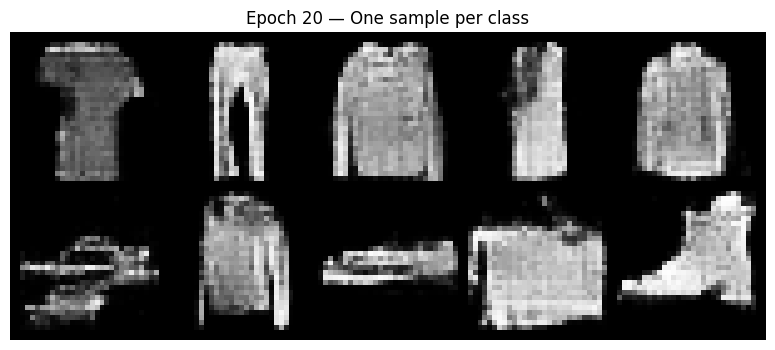

Epoch 30: 100%|██████████| 468/468 [00:08<00:00, 54.03it/s, D_loss=0.5505, G_loss=0.9014]


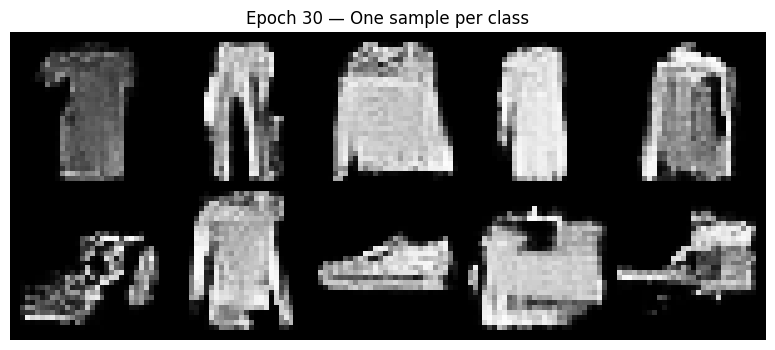

Epoch 40: 100%|██████████| 468/468 [00:08<00:00, 54.64it/s, D_loss=0.6054, G_loss=0.9724]


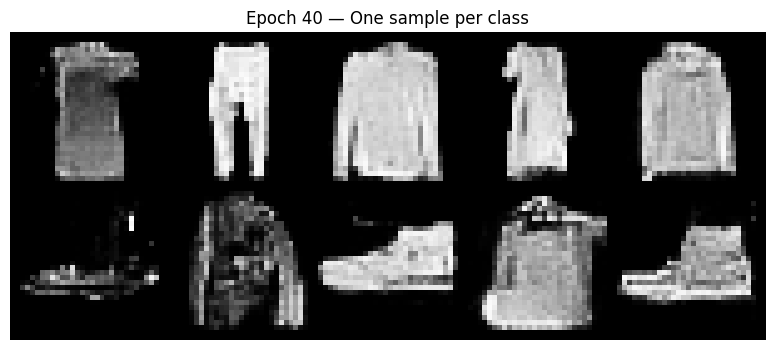

Epoch 50: 100%|██████████| 468/468 [00:08<00:00, 55.64it/s, D_loss=0.5917, G_loss=0.9254]


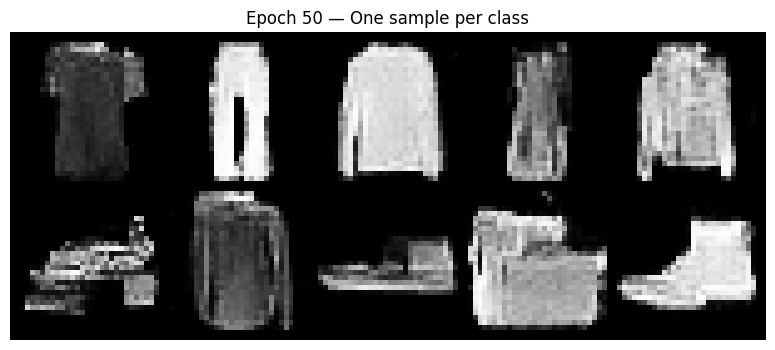


Learning Rate Tuning experiment completed!


In [9]:
lr_configs = {
    'Baseline': {'G': 0.0002, 'D': 0.0002},
    'Slow D': {'G': 0.0002, 'D': 0.0001},      # Half learning rate for D
    'Fast G': {'G': 0.0004, 'D': 0.0002},      # Double learning rate for G
    'Balanced': {'G': 0.0003, 'D': 0.00015}     # Adjusted both
}

print("Testing configuration: Slow D (G: 0.0002, D: 0.0001)")

G_lr = Generator(z_dim, num_classes, img_size, channels).to(device)
D_lr = Discriminator(img_size, channels, num_classes).to(device)

optimizer_G_lr = optim.Adam(G_lr.parameters(), lr=0.0002, betas=betas)
optimizer_D_lr = optim.Adam(D_lr.parameters(), lr=0.0001, betas=betas)

# Trainer
trainer_lr = GANTrainer(G_lr, D_lr, train_loader, device)

# Train with label smoothing + LR tuning
techniques_lr = {
    'label_smoothing': True
}

history_lr = trainer_lr.train(
    num_epochs=num_epochs,
    optimizer_G=optimizer_G_lr,
    optimizer_D=optimizer_D_lr,
    criterion=criterion,
    techniques=techniques_lr,
    save_interval=10
)

print("\nLearning Rate Tuning experiment completed!")

### Gradient Penalty

**Theory:**
Gradient penalty (as used in WGAN-GP) enforces the Lipschitz constraint by penalizing the norm of the discriminator's gradients. This:
- Stabilizes training
- Prevents the discriminator from becoming too powerful
- Provides meaningful gradients everywhere

We'll add a gradient penalty term to the discriminator loss.

In [10]:
class GANTrainerWithGP(GANTrainer):
    """Extended trainer with Gradient Penalty support"""
    
    def compute_gradient_penalty(self, real_imgs, fake_imgs, labels):
        """Compute WGAN-GP style gradient penalty"""
        batch_size = real_imgs.size(0)
        
        # Generate random interpolation coefficient
        alpha = torch.rand(batch_size, 1, 1, 1).to(self.device)
        alpha = alpha.expand_as(real_imgs)
        
        # Interpolate between real and fake
        interpolated = alpha * real_imgs + (1 - alpha) * fake_imgs
        interpolated.requires_grad_(True)
        
        # Compute discriminator output for interpolated images
        d_interpolated = self.D(interpolated, labels)
        
        # Compute gradients
        gradients = torch.autograd.grad(
            outputs=d_interpolated,
            inputs=interpolated,
            grad_outputs=torch.ones_like(d_interpolated),
            create_graph=True,
            retain_graph=True,
        )[0]
        
        # Compute gradient penalty
        gradients = gradients.view(batch_size, -1)
        gradient_norm = gradients.norm(2, dim=1)
        gradient_penalty = ((gradient_norm - 1) ** 2).mean()
        
        return gradient_penalty
    
    def train_epoch(self, optimizer_G, optimizer_D, criterion, epoch, techniques={}):
        self.G.train()
        self.D.train()
        
        epoch_g_loss = 0
        epoch_d_loss = 0
        
        pbar = tqdm(self.train_loader, desc=f"Epoch {epoch}")
        
        for i, (real_imgs, labels) in enumerate(pbar):
            real_imgs = real_imgs.to(self.device)
            labels = labels.to(self.device)
            current_batch_size = real_imgs.size(0)
            
            # train Discriminator
            optimizer_D.zero_grad()
            
            # Real images
            real_validity = self.D(real_imgs, labels)
            
            # Labels with optional smoothing
            if techniques.get('label_smoothing', False):
                real_target = torch.ones(current_batch_size, 1, device=self.device) * 0.9
                fake_target = torch.zeros(current_batch_size, 1, device=self.device) + 0.1
            else:
                real_target = torch.ones(current_batch_size, 1, device=self.device)
                fake_target = torch.zeros(current_batch_size, 1, device=self.device)
            
            real_loss = criterion(real_validity, real_target)
            
            # Fake images
            z = torch.randn(current_batch_size, z_dim, device=self.device)
            fake_imgs = self.G(z, labels)
            fake_validity = self.D(fake_imgs.detach(), labels)
            fake_loss = criterion(fake_validity, fake_target)
            
            # Base discriminator loss
            d_loss = (real_loss + fake_loss) / 2
            
            # Add gradient penalty if specified
            if techniques.get('gradient_penalty', False):
                gp = self.compute_gradient_penalty(real_imgs, fake_imgs.detach(), labels)
                gp_weight = techniques.get('gp_weight', 10)  # Standard weight is 10
                d_loss = d_loss + gp_weight * gp
            
            d_loss.backward()
            optimizer_D.step()
            
            # train Generator
            optimizer_G.zero_grad()
            
            z = torch.randn(current_batch_size, z_dim, device=self.device)
            fake_imgs = self.G(z, labels)
            fake_validity = self.D(fake_imgs, labels)
            
            g_loss = criterion(fake_validity, torch.ones(current_batch_size, 1, device=self.device))
            g_loss.backward()
            optimizer_G.step()
            
            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
            
            pbar.set_postfix({
                "D_loss": f"{d_loss.item():.4f}",
                "G_loss": f"{g_loss.item():.4f}"
            })
        
        # Average losses
        avg_g_loss = epoch_g_loss / len(self.train_loader)
        avg_d_loss = epoch_d_loss / len(self.train_loader)
        
        return avg_g_loss, avg_d_loss

Epoch 1: 100%|██████████| 468/468 [00:09<00:00, 48.21it/s, D_loss=0.6814, G_loss=0.7070]


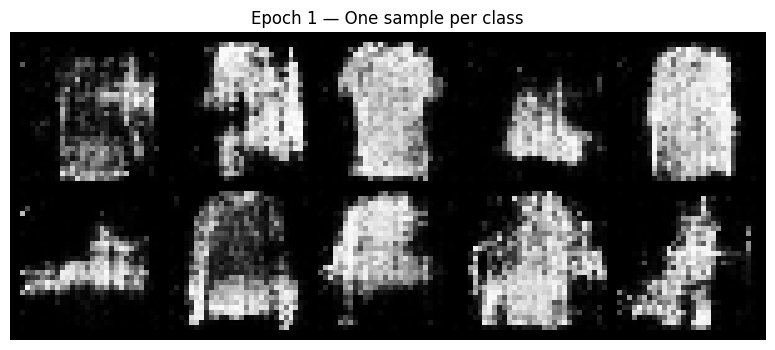

Epoch 10: 100%|██████████| 468/468 [00:09<00:00, 50.13it/s, D_loss=0.6094, G_loss=0.9490]


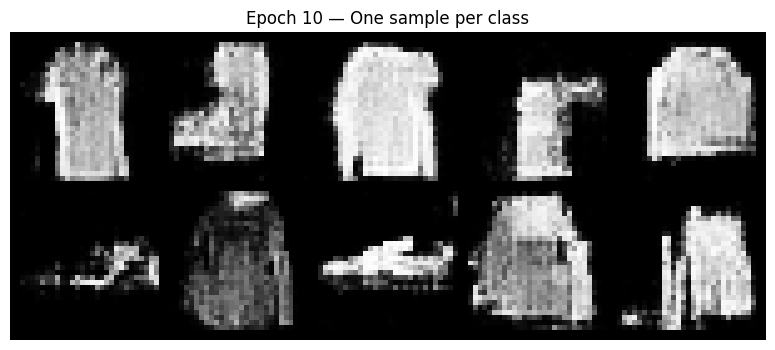

Epoch 20: 100%|██████████| 468/468 [00:09<00:00, 49.71it/s, D_loss=0.5913, G_loss=1.0315]


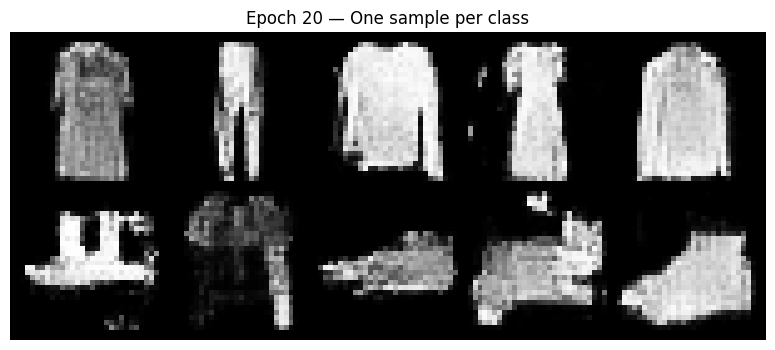

Epoch 30: 100%|██████████| 468/468 [00:09<00:00, 49.11it/s, D_loss=0.5424, G_loss=1.1164]


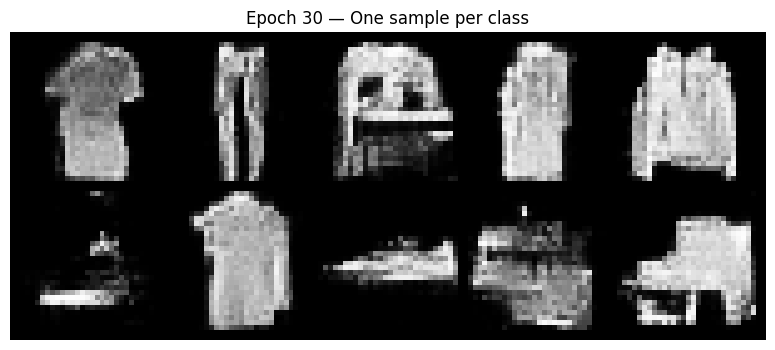

Epoch 40: 100%|██████████| 468/468 [00:09<00:00, 49.62it/s, D_loss=0.6323, G_loss=0.9907]


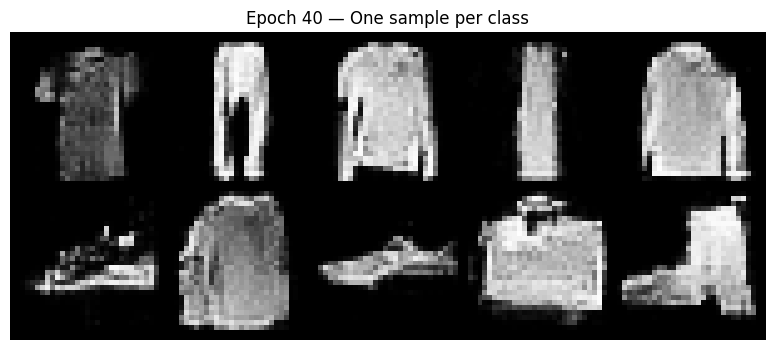

Epoch 50: 100%|██████████| 468/468 [00:09<00:00, 49.59it/s, D_loss=0.5332, G_loss=1.1318]


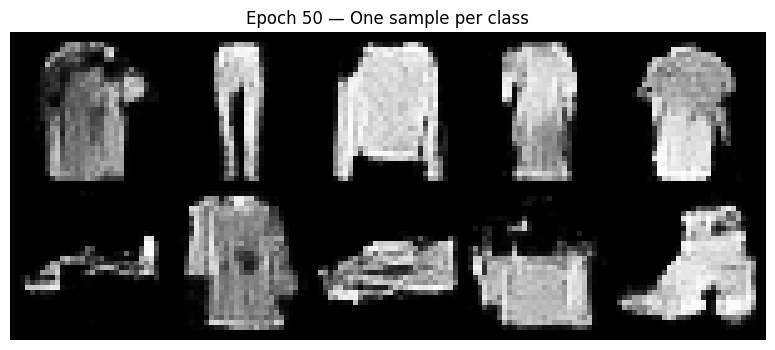


Gradient Penalty experiment completed!


In [11]:
G_gp = Generator(z_dim, num_classes, img_size, channels).to(device)
D_gp = Discriminator(img_size, channels, num_classes).to(device)

optimizer_G_gp = optim.Adam(G_gp.parameters(), lr=0.0002, betas=betas)
optimizer_D_gp = optim.Adam(D_gp.parameters(), lr=0.0001, betas=betas)

# Use enhanced trainer
trainer_gp = GANTrainerWithGP(G_gp, D_gp, train_loader, device)

# Train with label smoothing + LR tuning + gradient penalty
techniques_gp = {
    'label_smoothing': True,
    'gradient_penalty': True,
    'gp_weight': 10
}

history_gp = trainer_gp.train(
    num_epochs=num_epochs,
    optimizer_G=optimizer_G_gp,
    optimizer_D=optimizer_D_gp,
    criterion=criterion,
    techniques=techniques_gp,
    save_interval=10
)

print("\nGradient Penalty experiment completed!")

## Intermediate Results Analysis

Let's compare all experiments so far to see which techniques are most effective.

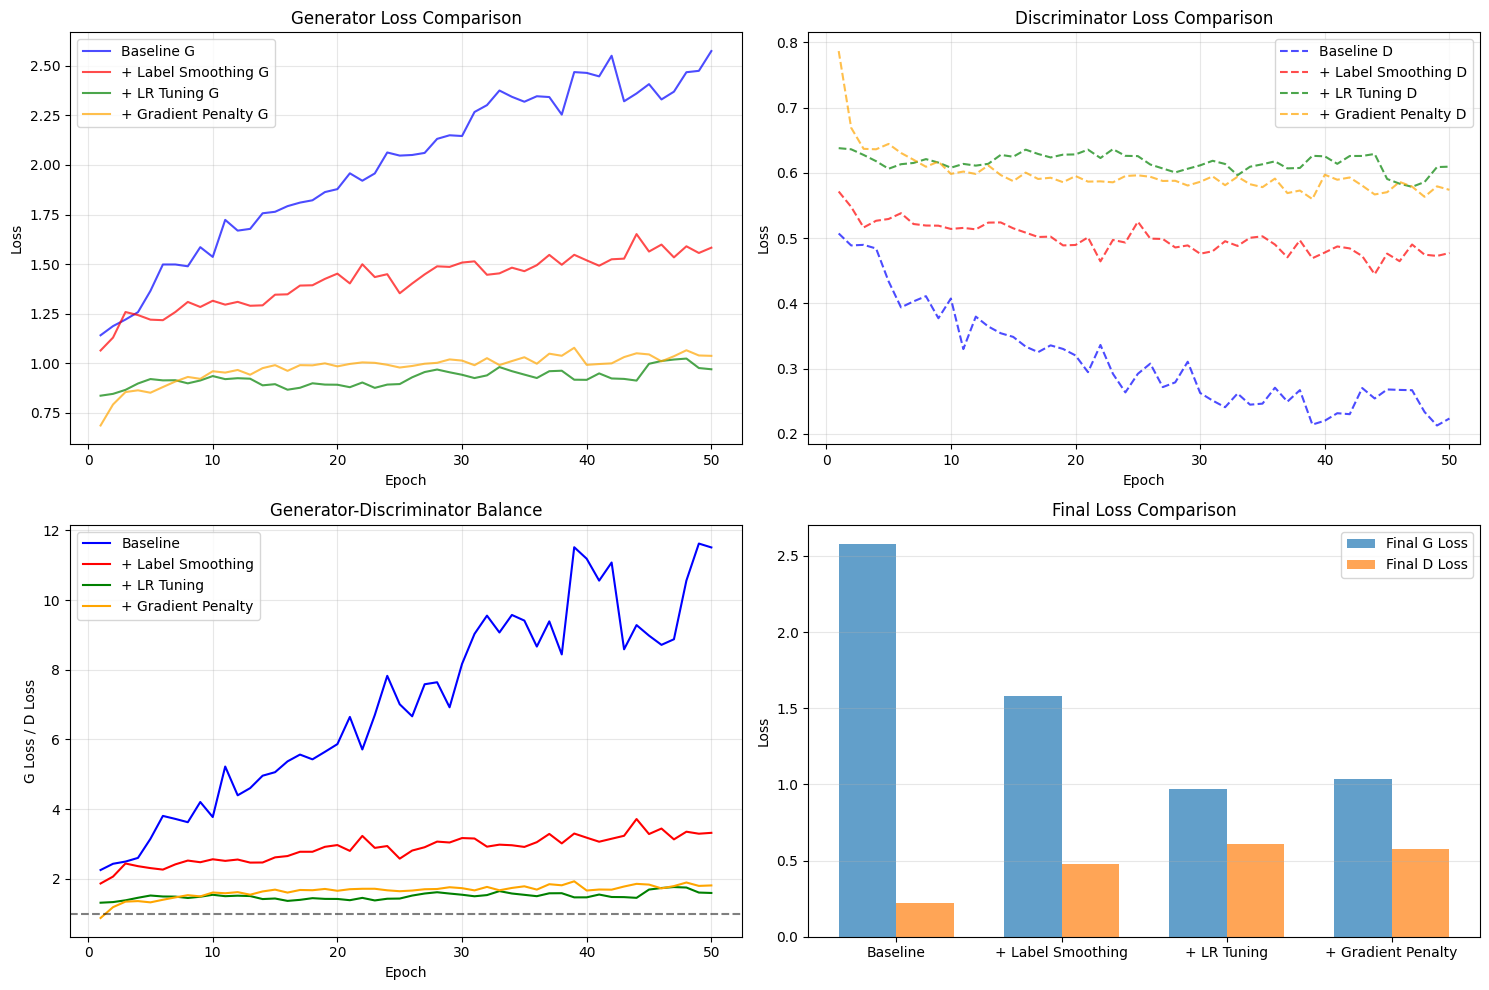

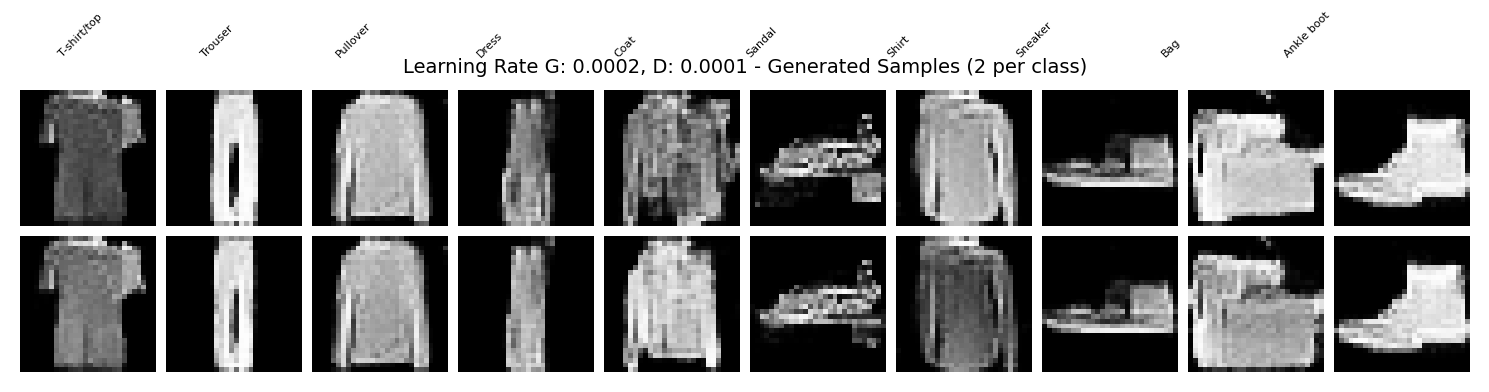

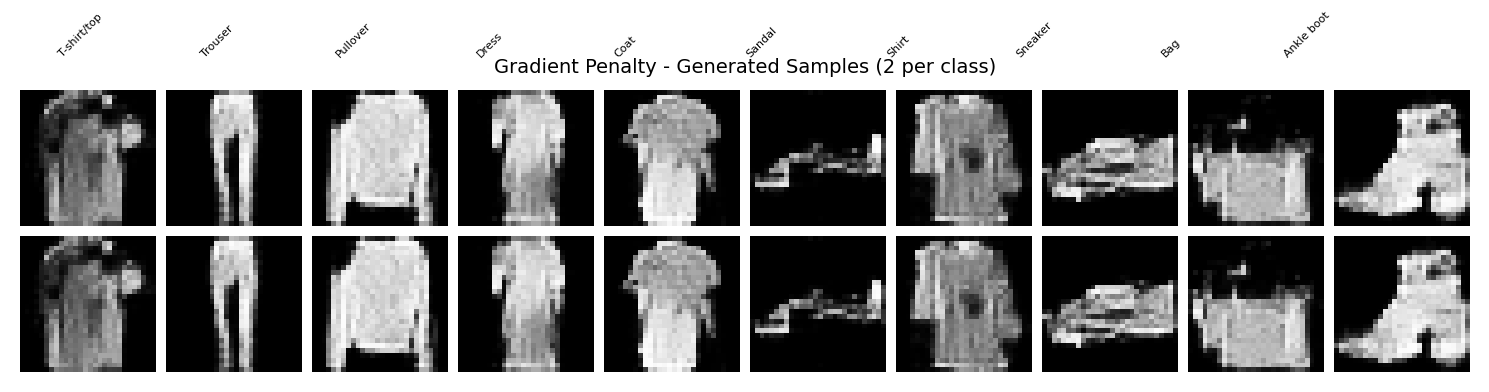

In [12]:
histories_all = {
    'Baseline': baseline_history,
    '+ Label Smoothing': history_ls,
    '+ LR Tuning': history_lr,
    '+ Gradient Penalty': history_gp
}

compare_experiments(histories_all, list(histories_all.keys()))

display_experiment_samples(trainer_lr, "Learning Rate G: 0.0002, D: 0.0001")
display_experiment_samples(trainer_gp, "Gradient Penalty")